In [54]:
import torch
import numpy as np
torch.__version__


'2.9.0+cpu'

In [55]:
#练习np的广播机制
A = np.array([[1, 2],[3,4]])
print(A)
print('-'*50)
B = np.array([10])
print(B)
print('-'*50)
print(A*B)
print('-'*50)
B = np.array([10,20])
print('-'*50)
print(B)
A*B

[[1 2]
 [3 4]]
--------------------------------------------------
[10]
--------------------------------------------------
[[10 20]
 [30 40]]
--------------------------------------------------
--------------------------------------------------
[10 20]


array([[10, 40],
       [30, 80]])

In [56]:
# 访问元素
X = np.array([[51,55],[14,19],[0,41]])#三行二列
print(X)
X[0]#取出第一行
X[0][1]#取出第一行一列的


[[51 55]
 [14 19]
 [ 0 41]]


np.int64(55)

# 从零实现softmax

引入的Fashion-MNIST数据集， 并设置数据迭代器的批量大小为256。

In [57]:
import torch
from IPython import display
from d2l import torch as d2l
#pip install d2l==0.17.6 --no-deps 解决冲突
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)#加载内置数据

批次形状: torch.Size([256, 1, 28, 28])
标签形状: torch.Size([256])


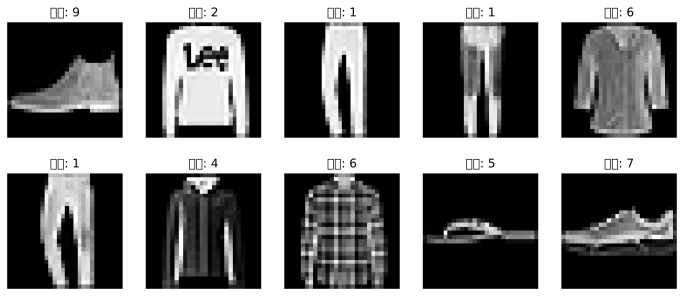

In [58]:
import matplotlib.pyplot as plt

# 只取第一个批次看看
for X, y in test_iter:
    print(f"批次形状: {X.shape}")  # torch.Size([256, 1, 28, 28])
    print(f"标签形状: {y.shape}")  # torch.Size([256])

    # 可视化前几个样例
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for i in range(10):
        ax = axes[i//5, i%5]
        img = X[i].squeeze()  # 去掉通道维度 (1, 28, 28) -> (28, 28)
        ax.imshow(img.numpy(), cmap='gray')
        ax.set_title(f"标签: {y[i].item()}")
        ax.axis('off')
    plt.show()

    break  # 只看第一个批次

初始化模型参数

In [59]:
num_inputs = 784    # 输入特征数 = 28×28 = 784（如图像的展平像素）
num_outputs = 10    # 输出类别数 = 10
"""
形状  ：(784, 10)，从输入到输出的连接权重
  初始化  ：从正态分布采样，均值=0，标准差=0.01
  requires_grad=True  ：启用自动梯度计算，用于反向传播
"""
W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)# 权重矩阵 W
print(f'W为{W}')
"""
  形状  ：(10,)，每个输出类别一个偏置
  初始化  ：全零初始化
同样启用梯度计算
"""
b = torch.zeros(num_outputs, requires_grad=True)# 偏置向量 b
# 输出 = 输入 × W + b ,定义了一个线性模型

W为tensor([[-6.5355e-05,  3.6598e-03, -2.2518e-02,  ..., -5.9378e-03,
         -1.5286e-02,  1.2977e-02],
        [ 9.0836e-03, -1.2281e-02, -1.6333e-03,  ...,  4.4104e-03,
         -1.1346e-02,  3.7233e-03],
        [ 2.9238e-03,  1.1881e-02,  1.3982e-02,  ..., -1.2863e-02,
          8.0691e-03, -6.7650e-03],
        ...,
        [ 6.0221e-03,  7.6323e-03,  3.5545e-03,  ...,  1.8315e-02,
          1.8184e-02,  8.5686e-03],
        [-5.6990e-03,  1.8854e-03,  8.1107e-03,  ...,  9.7336e-03,
          9.8842e-03, -1.0537e-03],
        [ 1.0576e-02, -7.6425e-03,  5.0175e-03,  ...,  1.5141e-02,
         -1.1382e-03, -7.7919e-03]], requires_grad=True)


定义softmax操作

In [60]:
X = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])#张亮为2*3
print(X)
X.sum(0, keepdim=True)#按照轴0求和
X.sum(1, keepdim=True)#keepdim保持维数

tensor([[1., 2., 3.],
        [4., 5., 6.]])


tensor([[ 6.],
        [15.]])

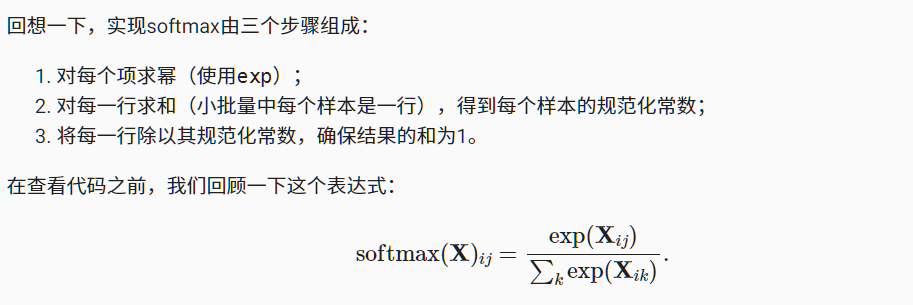

In [61]:
def softmax(X):
    X_exp = torch.exp(X)
    # print('-'*50)
    # print(X_exp)
    # print('-'*50)
    partition = X_exp.sum(1, keepdim=True)#对每一行求和，保持维数不变
    # print(partition)
    # print('-'*50)
    return X_exp / partition  # 这里应用了广播机制

In [62]:
"""
torch.normal: 这是PyTorch中的一个函数，用于从正态分布（高斯分布）中生成随机数。
参数0: 正态分布的均值（mean）。
参数1: 正态分布的标准差（std）。
(2,5): 指定输出张量的形状，这里是2行5列，即一个2x5的矩阵。
"""
X = torch.normal(0, 1, (2, 5))#均值为0，方差为1的均匀分布，构造（2，5）张量
X_prob = softmax(X)
X_prob, X_prob.sum(1)

(tensor([[0.0603, 0.5276, 0.1003, 0.1511, 0.1608],
         [0.0515, 0.0281, 0.8530, 0.0465, 0.0210]]),
 tensor([1.0000, 1.0000]))

In [63]:
0.1733+0.1290+0.0866+ 0.3178+0.2933

1.0

定义模型
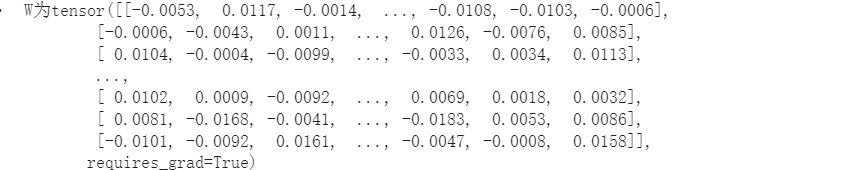

In [64]:
def net(X):
  # # 不同形状的输入都会被重塑为 (batch_size, 784)
    return softmax(torch.matmul(X.reshape((-1, W.shape[0])), W) + b)#matmul矩阵相乘
    #这样返回的是线性回归模型


In [65]:
W.shape[0]#第一列的维度大小，及行数
# torch.matmul(X.reshape((-1, W.shape[0])), W) + b



784

定义损失函数

In [66]:
y = torch.tensor([0, 2])#PyTorch 中​​创建张量​​的函数。
print(y)
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y_hat[[0, 1], y]
#二维索引y_hat[[0, 1], y]
# 等价于：
# 取两个位置的元素：
# 1. 位置：[行=0, 列=y[0]=0] → y_hat[0, 0]
# 2. 位置：[行=1, 列=y[1]=2] → y_hat[1, 2]

tensor([0, 2])


tensor([0.1000, 0.5000])

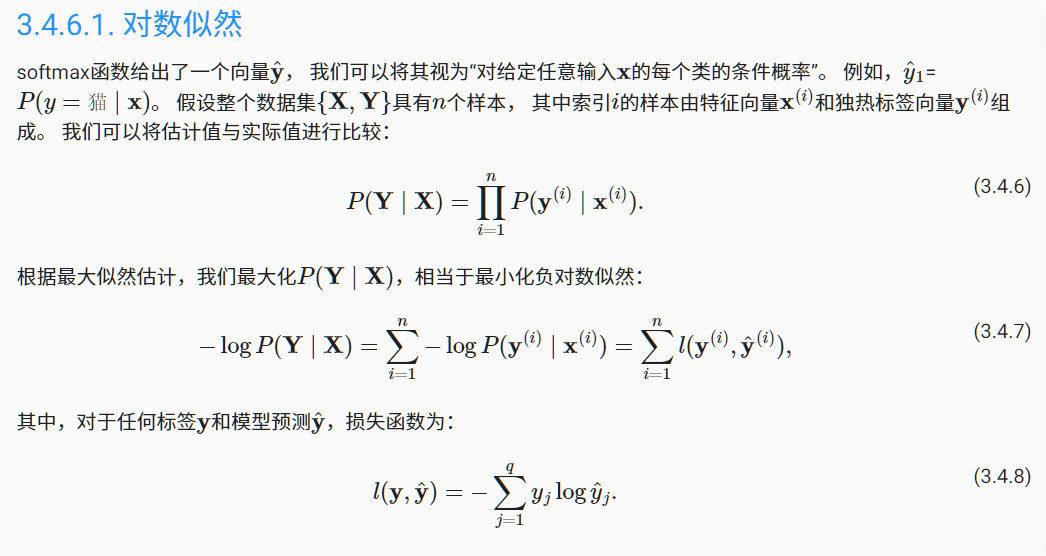

In [67]:
y_hat,y,len(y_hat)

(tensor([[0.1000, 0.3000, 0.6000],
         [0.3000, 0.2000, 0.5000]]),
 tensor([0, 2]),
 2)

In [68]:
def cross_entropy(y_hat, y):#损失函数
    return - torch.log(y_hat[range(len(y_hat)), y])#行索引，列索引，一一匹配
    """"
    # 传入两个索引数组：
    # 行索引： [0, 1]
    # 列索引： y = [0, 2]

    # PyTorch 配对提取：
    # 第一个配对：行0, 列0 → y_hat[0, 0] = 0.1000
    # 第二个配对：行1, 列2 → y_hat[1, 2] = 0.5000

    selected_probs = y_hat[[0, 1], [0, 2]]
    # selected_probs = tensor([0.1000, 0.5000])
    """
"""
# 计算每个值的自然对数：
# log(0.1000) = ln(0.1) ≈ -2.3026
# log(0.5000) = ln(0.5) ≈ -0.6931

log_probs = torch.log(tensor([0.1000, 0.5000]))
# log_probs ≈ tensor([-2.3026, -0.6931])
"""
print(y_hat[range(len(y_hat))])
print(y)
cross_entropy(y_hat, y)

tensor([[0.1000, 0.3000, 0.6000],
        [0.3000, 0.2000, 0.5000]])
tensor([0, 2])


tensor([2.3026, 0.6931])

In [69]:
y_hat.argmax(axis=1)


tensor([2, 2])

In [70]:
def accuracy(y_hat, y):
    """计算预测正确的数量"""
    # 步骤1：如果是多分类输出，取概率最大的类别作为预测
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
        # y_hat原本可能是概率分布，如 [0.1, 0.3, 0.6]
        # argmax(axis=1) 取每行最大值的索引
        # 例如：# 找到每个样本概率最大的类别：
        # 样本0: [0.1, 0.3, 0.6] → 最大值0.6在索引2 → 预测类别2
        # 样本1: [0.3, 0.2, 0.5] → 最大值0.5在索引2 → 预测类别2
        # y_hat.argmax(axis=1)为tensor([2, 2])一维向量
    cmp = y_hat.type(y.dtype) == y# 步骤2：比较预测和真实标签
    return float(cmp.type(y.dtype).sum())# 确保数据类型一致后比较，得到布尔数组 步骤3：统计True的数量并转为float
accuracy(y_hat, y) / len(y)

0.5

In [71]:
def evaluate_accuracy(net, data_iter):
    """计算在指定数据集上模型的精度"""
    if isinstance(net, torch.nn.Module):# 1. 如果net是PyTorch的nn.Module，设置为评估模式
        net.eval()  # 将模型设置为评估模式
    # 2. 创建累加器，用于累加正确预测数和总样本数
    metric = Accumulator(2)  # 两个值：[正确数累计, 总数累计]
    with torch.no_grad():# 3. 禁用梯度计算，节省内存和计算资源
        for X, y in data_iter: # 4. 遍历数据集
            metric.add(accuracy(net(X), y), y.numel())
            # accuracy(net(X), y): 这个batch中预测正确的数量
            # y.numel(): 这个batch的样本总数
    return metric[0] / metric[1]# 总正确数 / 总样本数

In [72]:
class Accumulator:
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]
evaluate_accuracy(net, test_iter)#直接用的内置数据集

0.0595

In [81]:
Accumulator(3)#调用init函数了
# 相当于：
# metric = Accumulator(n=3)  # 创建一个Accumulator对象，初始化3个累加值

训练模型
1. 设置模型为训练模式
2. 遍历所有训练batch：
   a. 前向传播得到预测
   b. 计算损失
   c. 反向传播计算梯度
   d. 优化器更新参数
   e. 记录统计信息
3. 计算整个epoch的平均损失和准确率

参数说明：

net: 神经网络模型

train_iter: 训练数据迭代器（每次返回一个batch）

loss: 损失函数（如交叉熵损失）

updater: 优化器（如SGD、Adam）

In [84]:
y.numel(),y

(2, tensor([0, 2]))

In [82]:
def train_epoch_ch3(net, train_iter, loss, updater):
    """训练模型一个迭代周期（定义见第3章）"""
    # 将模型设置为训练模式
    if isinstance(net, torch.nn.Module):
        net.train()
    # 训练损失总和、训练准确度总和、样本数
    metric = Accumulator(3)# 2. 创建累加器，记录3个值：总损失、总正确数、总样本数
    for X, y in train_iter:# 3. 遍历训练数据的所有batch
        # 计算梯度并更新参数
        y_hat = net(X)# 4. 前向传播：计算预测
        l = loss(y_hat, y)# 5. 计算损失
        if isinstance(updater, torch.optim.Optimizer):# 6. 反向传播和参数更新
            # 使用PyTorch内置的优化器和损失函数
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            # 使用定制的优化器和损失函数
            l.sum().backward()
            updater(X.shape[0])
        # 7. 累加统计信息
        metric.add(float(l.sum()),         # 当前batch的总损失
                   accuracy(y_hat, y), # 当前batch的正确预测数
                   y.numel())      # 当前batch的样本数
    # 返回训练损失和训练精度
    return metric[0] / metric[2], metric[1] / metric[2]

In [74]:
class Animator:
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量地绘制多条线
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向图表中添加多个数据点
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

In [75]:
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    """训练模型（定义见第3章）"""
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):  # 2. 训练多个epoch
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)# 返回训练损失和训练精度
        test_acc = evaluate_accuracy(net, test_iter)# 4. 在测试集上评估准确率
        animator.add(epoch + 1, train_metrics + (test_acc,))#将当前epoch的结果添加到可视化器中
    train_loss, train_acc = train_metrics# 6. 训练完成后，获取最终的训练指标
    # 7. 断言检查，确保训练效果合理
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc

In [76]:
lr = 0.1

def updater(batch_size):
    return d2l.sgd([W, b], lr, batch_size)

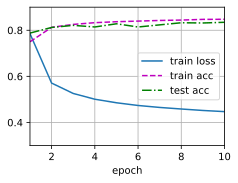

In [77]:
num_epochs = 10
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

预测

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


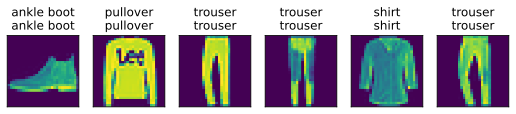

In [85]:
def predict_ch3(net, test_iter, n=6):
    """预测标签（定义见第3章）"""
    for X, y in test_iter:
        break
    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    d2l.show_images(
        X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])

predict_ch3(net, test_iter)